<a href="https://colab.research.google.com/github/divya910agarwal/nifty50-volatility-modeling/blob/main/Volatility_Modeling_and_Forecasting_with_rolling_window.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Volatility Modeling and Forecasting — Nifty 50

This project fits and compares a family of GARCH-type models on 30 years of Nifty 50 daily returns.  
The workflow covers:
1. Data ingestion and cleaning
2. In-sample model fitting (GARCH, EGARCH, GJR-GARCH, APARCH) with AIC/BIC comparison
3. Rolling-window out-of-sample forecasting (window sizes: 100, 500, 1000)
4. Forecast evaluation via MSE/MAE and Diebold-Mariano tests
5. Mincer-Zarnowitz regression for forecast unbiasedness

**Key findings:** GJR-GARCH is superior in-sample (AIC/BIC); APARCH is superior out-of-sample (MSE/MAE); leverage effect confirmed in Nifty 50.

## 0. Setup

In [1]:
!pip install arch --quiet

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import itertools
from scipy import stats
from arch import arch_model


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 10.1 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Data Ingestion and Cleaning

Upload `ND30Y.csv` — 30 years of Nifty 50 daily closing prices (source: NSE / investing.com).  
The file has `Date` and `Price` columns; prices are stored as comma-formatted strings.

In [5]:
filepath="/content/drive/MyDrive/ND30Y.csv"

In [7]:
data = pd.read_csv(filepath)

data['Date']  = pd.to_datetime(data['Date'], dayfirst=True)
data['Price'] = pd.to_numeric(data['Price'].str.replace(',', ''), errors='coerce')
data.sort_values('Date', inplace=True)
data.reset_index(drop=True, inplace=True)

data.ffill(inplace=True)

data['Log_Returns'] = np.log(data['Price'] / data['Price'].shift(1))

print(f"Rows: {len(data)} | Date range: {data['Date'].min().date()} → {data['Date'].max().date()}")
print(f"Missing values:\n{data.isnull().sum()}")
data.tail()

Rows: 7152 | Date range: 1995-11-06 → 2024-08-05
Missing values:
Date             0
Price            0
Open             0
High             0
Low              0
Vol.           289
Change %         0
Log_Returns      1
dtype: int64


,Date,Price,Open,High,Low,Vol.,Change %,Log_Returns
7147,2024-07-30,24857.30,"24,839.40","24,971.75","24,798.65",384.99M,0.09%,0.000853
7148,2024-07-31,24951.15,"24,886.70","24,984.60","24,856.50",333.65M,0.38%,0.003768
7149,2024-08-01,25010.90,"25,030.95","25,078.30","24,956.40",431.31M,0.24%,0.002392
7150,2024-08-02,24717.70,"24,789.00","24,851.90","24,686.85",345.03M,-1.17%,-0.011792
7151,2024-08-05,24055.60,"24,302.85","24,350.05","23,893.70",487.00M,-2.68%,-0.027152


### 1.1 Exploratory Plots

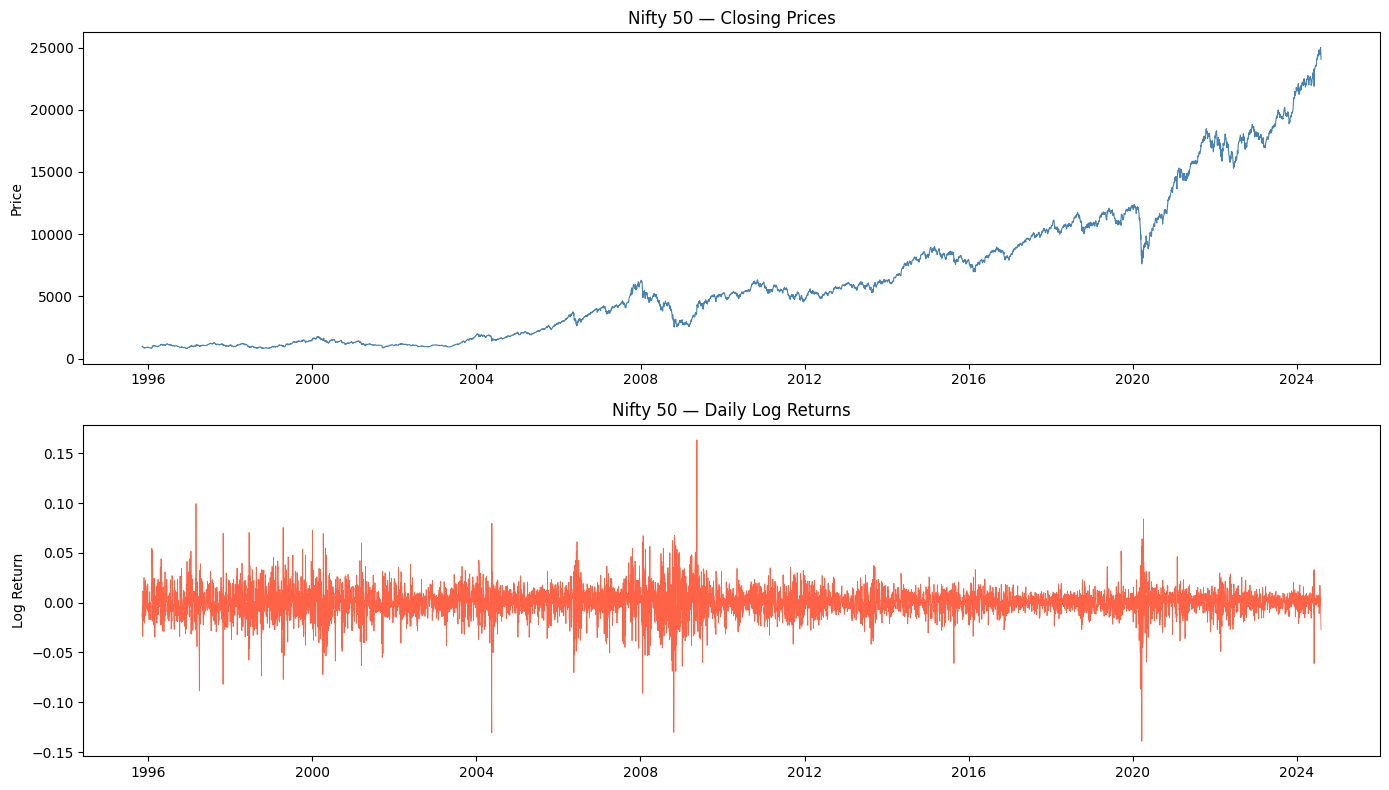


Return summary:
count    7151.000000
mean        0.000446
std         0.014479
min        -0.139038
25%        -0.006243
50%         0.000845
75%         0.007653
max         0.163343
Name: Log_Returns, dtype: float64

Single-day drops > 5%: 44


In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(data['Date'], data['Price'], color='steelblue', linewidth=0.8)
axes[0].set_title('Nifty 50 — Closing Prices')
axes[0].set_ylabel('Price')

axes[1].plot(data['Date'], data['Log_Returns'], color='tomato', linewidth=0.6)
axes[1].set_title('Nifty 50 — Daily Log Returns')
axes[1].set_ylabel('Log Return')

plt.tight_layout()
plt.show()

print(f"\nReturn summary:")
print(data['Log_Returns'].describe().round(6))

large_drops = data[data['Log_Returns'] < -0.05][['Date', 'Log_Returns']]
print(f"\nSingle-day drops > 5%: {len(large_drops)}")

### 1.2 Save Cleaned Data to Drive

In [9]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE = '/content/drive/My Drive'
data.to_csv(f'{DRIVE}/cND30Y.csv', index=False)
print('Saved cND30Y.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved cND30Y.csv


## 2. In-Sample Model Fitting

We scale log returns by 100 (standard practice for numerical stability in GARCH estimation)  
and fit four asymmetric volatility models:

| Model | Captures |
|-------|----------|
| GARCH(1,1) | Symmetric volatility clustering |
| EGARCH(1,1) | Asymmetry via log-variance |
| GJR-GARCH(1,1) | Leverage effect via threshold term |
| APARCH(1,1) | Power transformation + asymmetry |

In [10]:
returns_data   = data['Log_Returns'].dropna()
scaled_returns = returns_data * 100

In [11]:
models_spec = {
    'GARCH(1,1)':   arch_model(scaled_returns, vol='Garch',  p=1, q=1),
    'EGARCH(1,1)':  arch_model(scaled_returns, vol='EGarch', p=1, q=1),
    'GJR-GARCH(1,1)': arch_model(scaled_returns, vol='Garch', p=1, q=1, o=1),
    'APARCH(1,1)':  arch_model(scaled_returns, vol='APARCH', p=1, q=1),
}

fits = {name: spec.fit(disp='off') for name, spec in models_spec.items()}

aic_bic = pd.DataFrame(
    {name: {'AIC': fit.aic, 'BIC': fit.bic} for name, fit in fits.items()}
).T.sort_values('AIC')

print('In-sample AIC / BIC comparison:')
print(aic_bic.round(2))

In-sample AIC / BIC comparison:
                     AIC       BIC
GJR-GARCH(1,1)  23007.95  23042.32
APARCH(1,1)     23083.03  23117.41
GARCH(1,1)      23083.03  23110.53
EGARCH(1,1)     23105.79  23133.29


In [12]:
for name, fit in fits.items():
    print(f'\n{"-"*60}\n{name}\n{"-"*60}')
    print(fit.summary())


------------------------------------------------------------
GARCH(1,1)
------------------------------------------------------------
                     Constant Mean - GARCH Model Results                      
Dep. Variable:            Log_Returns   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -11537.5
Distribution:                  Normal   AIC:                           23083.0
Method:            Maximum Likelihood   BIC:                           23110.5
                                        No. Observations:                 7151
Date:                Tue, Mar 10 2026   Df Residuals:                     7150
Time:                        16:43:34   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
-----

### 2.1 Conditional Volatility — All Models

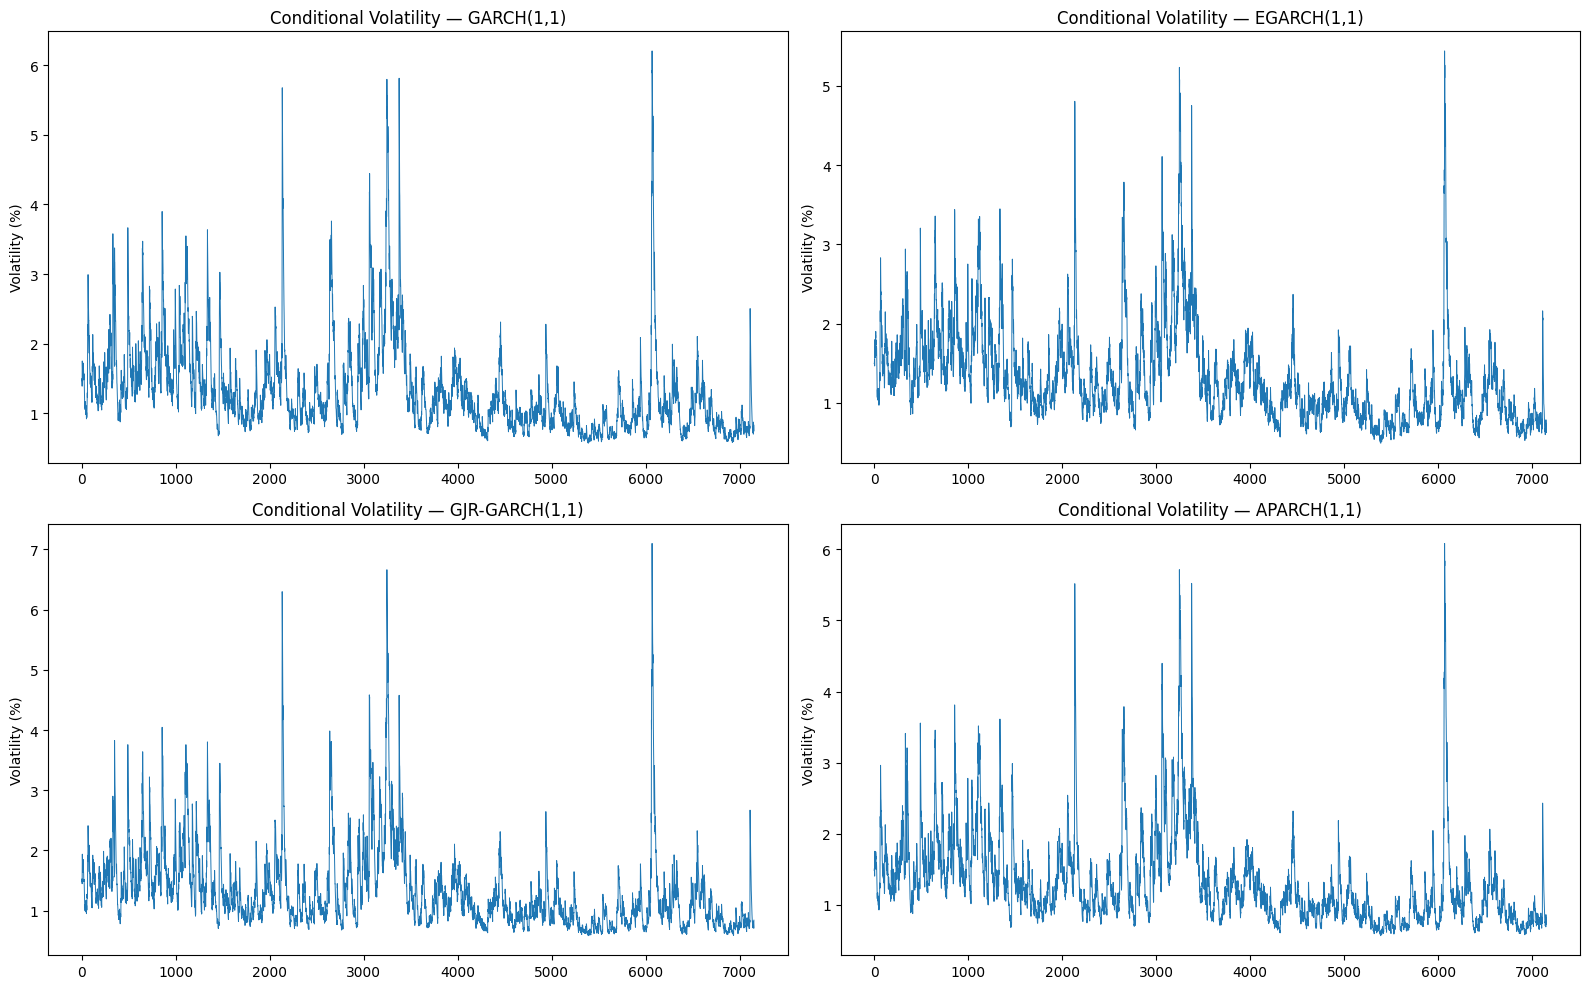

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, (name, fit) in zip(axes, fits.items()):
    ax.plot(fit.conditional_volatility, linewidth=0.7)
    ax.set_title(f'Conditional Volatility — {name}')
    ax.set_ylabel('Volatility (%)')

plt.tight_layout()
plt.show()

## 3. Rolling-Window Out-of-Sample Forecasting

Expanding-window 1-step-ahead forecasts using window sizes of 100, 500, and 1000 days.  
Models: GARCH(1,1), EGARCH(1,1), GJR-GARCH(1,1), APARCH(1,1).

In [14]:
def rolling_forecast(returns, vol_type, window, p=1, q=1, o=0):
    preds = []
    for i in range(window, len(returns)):
        train = returns[:i]
        fit   = arch_model(train, vol=vol_type, p=p, q=q, o=o).fit(disp='off')
        preds.append(fit.forecast(horizon=1).variance.values[-1, 0])
    return preds

In [15]:
print('Rolling GARCH(1,1)...')
forecasts_garch_100  = rolling_forecast(scaled_returns, 'Garch', 100)
forecasts_garch_500  = rolling_forecast(scaled_returns, 'Garch', 500)
forecasts_garch_1000 = rolling_forecast(scaled_returns, 'Garch', 1000)
print('Done.')

Rolling GARCH(1,1)...
Done.


In [16]:
print('Rolling EGARCH(1,1)...')
forecasts_egarch_100  = rolling_forecast(scaled_returns, 'EGarch', 100)
forecasts_egarch_500  = rolling_forecast(scaled_returns, 'EGarch', 500)
forecasts_egarch_1000 = rolling_forecast(scaled_returns, 'EGarch', 1000)
print('Done.')

Rolling EGARCH(1,1)...
Done.


In [ ]:

print('Rolling GJR-GARCH(1,1)...')
forecasts_gjr_100  = rolling_forecast(scaled_returns, 'Garch', 100,  o=1)
forecasts_gjr_500  = rolling_forecast(scaled_returns, 'Garch', 500,  o=1)
forecasts_gjr_1000 = rolling_forecast(scaled_returns, 'Garch', 1000, o=1)
print('Done.')

Rolling GJR-GARCH(1,1)...


In [ ]:
print('Rolling APARCH(1,1)...')
forecasts_aparch_500  = rolling_forecast(scaled_returns, 'APARCH', 500)
forecasts_aparch_1000 = rolling_forecast(scaled_returns, 'APARCH', 1000)
print('Done.')

### 3.1 Realized Volatility

21-day rolling realized volatility computed as:
$$RV_t = \sqrt{\sum_{i=0}^{20} r_{t-i}^2}$$
This is the standard proxy for latent daily volatility used in forecast evaluation.

In [ ]:
WINDOW_RV = 21
realized_volatility = np.sqrt(
    (scaled_returns ** 2).rolling(window=WINDOW_RV).sum()
)
realized_volatility = realized_volatility.dropna()
print(f'Realized volatility observations: {len(realized_volatility)}')

### 3.2 Assemble Forecast DataFrame

In [ ]:
def to_series(forecasts, returns_index, window):
    return pd.Series(forecasts, index=returns_index[window:])

idx = scaled_returns.index

forecast_df = pd.DataFrame({
    'Realized_Volatility':  realized_volatility,
    'GARCH_100':    to_series(forecasts_garch_100,  idx, 100),
    'GARCH_500':    to_series(forecasts_garch_500,  idx, 500),
    'GARCH_1000':   to_series(forecasts_garch_1000, idx, 1000),
    'EGARCH_100':   to_series(forecasts_egarch_100,  idx, 100),
    'EGARCH_500':   to_series(forecasts_egarch_500,  idx, 500),
    'EGARCH_1000':  to_series(forecasts_egarch_1000, idx, 1000),
    'GJR_100':      to_series(forecasts_gjr_100,  idx, 100),
    'GJR_500':      to_series(forecasts_gjr_500,  idx, 500),
    'GJR_1000':     to_series(forecasts_gjr_1000, idx, 1000),
    'APARCH_500':   to_series(forecasts_aparch_500,  idx, 500),
    'APARCH_1000':  to_series(forecasts_aparch_1000, idx, 1000),
}).dropna()

print(f'Aligned evaluation window: {len(forecast_df)} observations')
forecast_df.to_csv(f'{DRIVE}/forecasted_volatility.csv', index=True)
forecast_df.head()

## 4. Forecast Evaluation

### 4.1 Loss Functions (MSE and MAE)

In [ ]:
rv = forecast_df['Realized_Volatility']
model_cols = [c for c in forecast_df.columns if c != 'Realized_Volatility']

loss_df = pd.DataFrame({
    col: {
        'MSE': np.mean((rv - forecast_df[col]) ** 2),
        'MAE': np.mean(np.abs(rv - forecast_df[col])),
    }
    for col in model_cols
}).T.sort_values('MSE')

print('Out-of-sample loss metrics (sorted by MSE):')
print(loss_df.round(6))

loss_df.to_csv(f'{DRIVE}/loss_metrics.csv')

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

loss_df['MSE'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('MSE by Model')
axes[0].set_ylabel('MSE')
axes[0].tick_params(axis='x', rotation=45)

loss_df['MAE'].plot(kind='bar', ax=axes[1], color='tomato')
axes[1].set_title('MAE by Model')
axes[1].set_ylabel('MAE')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 4.2 Diebold-Mariano Test

The Diebold-Mariano (DM) test checks whether two forecasts have statistically different predictive accuracy.  
Under H₀: equal predictive ability. A positive statistic means model 1 has larger squared error (model 2 is better).

In [ ]:
def diebold_mariano_test(forecast_1, forecast_2, realized):
    combined = pd.concat([forecast_1, forecast_2, realized], axis=1).dropna()
    f1, f2, rv_ = combined.iloc[:, 0], combined.iloc[:, 1], combined.iloc[:, 2]

    d = (f1 - rv_) ** 2 - (f2 - rv_) ** 2
    mean_d  = d.mean()
    var_d   = d.var()

    if var_d == 0 or len(d) == 0:
        return np.nan, np.nan

    dm_stat = mean_d / np.sqrt(var_d / len(d))
    p_value = 2 * (1 - stats.norm.cdf(abs(dm_stat)))
    return round(dm_stat, 4), round(p_value, 4)


dm_results = {}
for m1, m2 in itertools.combinations(model_cols, 2):
    stat, pval = diebold_mariano_test(
        forecast_df[m1], forecast_df[m2], forecast_df['Realized_Volatility']
    )
    dm_results[(m1, m2)] = {'DM Statistic': stat, 'p-value': pval}

dm_df = pd.DataFrame(dm_results).T
dm_df.index.names = ['Model 1', 'Model 2']
print(dm_df)
dm_df.to_csv(f'{DRIVE}/dm_test_results.csv')

### 4.3 Mincer-Zarnowitz Regression

Regresses realized volatility on each model's forecast:  
$$RV_t = \alpha + \beta \hat{\sigma}_t + \varepsilon_t$$  
An unbiased forecast implies α = 0 and β = 1.

In [ ]:
mz_results = {}

for col in model_cols:
    aligned = forecast_df[['Realized_Volatility', col]].dropna()
    X = sm.add_constant(aligned[col])
    y = aligned['Realized_Volatility']
    res = sm.OLS(y, X).fit()
    mz_results[col] = {
        'alpha': round(res.params[0], 4),
        'beta':  round(res.params[1], 4),
        'R²':    round(res.rsquared, 4),
        'p(alpha=0)': round(res.pvalues[0], 4),
        'p(beta=1)':  round(stats.t.sf(abs((res.params[1] - 1) / res.bse[1]), df=res.df_resid) * 2, 4),
    }

mz_df = pd.DataFrame(mz_results).T
print('Mincer-Zarnowitz regression results:')
print(mz_df)
mz_df.to_csv(f'{DRIVE}/mincer_zarnowitz_results.csv')

## 5. Results Summary

In [ ]:
best_mse = loss_df['MSE'].idxmin()
best_mae = loss_df['MAE'].idxmin()
best_aic = aic_bic['AIC'].idxmin()
best_bic = aic_bic['BIC'].idxmin()

print('=' * 50)
print('RESULTS SUMMARY')
print('=' * 50)
print(f'Best in-sample  (AIC): {best_aic}')
print(f'Best in-sample  (BIC): {best_bic}')
print(f'Best out-of-sample (MSE): {best_mse}')
print(f'Best out-of-sample (MAE): {best_mae}')

print('\nLeverage effect check (GJR-GARCH gamma term):')
gjr_fit = fits['GJR-GARCH(1,1)']
gamma   = gjr_fit.params.get('gamma[1]', gjr_fit.params.get('gamma1', None))
pval    = gjr_fit.pvalues.get('gamma[1]', gjr_fit.pvalues.get('gamma1', None))
if gamma is not None:
    print(f'  gamma = {gamma:.4f}, p-value = {pval:.4f}')
    print(f'  Leverage effect: {"confirmed" if (gamma > 0 and pval < 0.05) else "not confirmed"}')

### 5.1 Forecast vs Realized Volatility (Best Models)

In [ ]:
top_models = loss_df.head(3).index.tolist()

plt.figure(figsize=(14, 6))
plt.plot(forecast_df.index, forecast_df['Realized_Volatility'],
         color='black', linewidth=1.2, label='Realized Volatility', alpha=0.8)

colors = ['steelblue', 'tomato', 'seagreen']
for model, color in zip(top_models, colors):
    plt.plot(forecast_df.index, forecast_df[model],
             linewidth=0.8, alpha=0.7, color=color, label=model)

plt.title('Realized vs Forecasted Volatility — Top 3 Models (by MSE)')
plt.ylabel('Volatility (%)')
plt.legend()
plt.tight_layout()
plt.show()